# Lipschitz Optimization Illustration
A notebook to show how Lipschitz optimization samples and bounds function values.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from vnn.datasets import LARD
from vnn.pwl import generate_samples
from vnn.transforms import Rotation, HomographyYaw
from vnn.visualization import setup_latex, get_figure_size, TEXTWIDTH_PT


setup_latex()

# Get image
dataset = LARD(size=64)
idx = 0
img = dataset[idx][0].numpy()  # Discard label

# Create transform
c, h, w = img.shape
xc = w // 2
yc = h // 2
transform = Rotation(xc, yc)
padding = 0.5
p_min = np.deg2rad(0)
p_max = np.deg2rad(10)

transform = HomographyYaw(f=10, xc=xc, yc=yc)

num_samples = 1000
padding_value = 0.5
samples, params = generate_samples(
    img,
    transform,
    lower_bound=p_min,
    upper_bound=p_max,
    num_samples=num_samples,
    padding=padding_value,
)

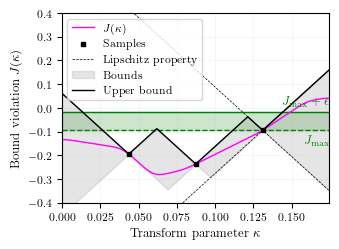

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Pixel of interest
c = 0
i = 21
j = 10

# Option 1: Use actual pixel curve
G = samples[:, c, i, j]
J = 0.5 - G

# Option 2: Smoothed out curve for the figure
kappa_observed = np.array([0.00, 0.04, 0.06, 0.08, 0.13, 0.16, 0.18])
J_kappa_observed = np.array([-0.13, -0.17, -0.29, -0.26, -0.10, 0.03, 0.05])
kappa_values = np.linspace(kappa_observed.min(), kappa_observed.max(), 1000)
J_kappa_values = np.interp(params, kappa_observed, J_kappa_observed)
J_kappa_values = gaussian_filter1d(J_kappa_values, sigma=25)
J = J_kappa_values

dJ = np.diff(J)
dK = np.diff(params)
L = np.max(np.abs(dJ / dK))

# fig_size = get_figure_size(width_pt=TEXTWIDTH_PT)
fig_size = get_figure_size(TEXTWIDTH_PT, fraction=1, aspect_ratio=1.4)
plt.figure(figsize=fig_size)

num_points = 3

indices = np.linspace(0, len(params), num_points + 2).astype(int)
indices = indices[1:-1]

ubs = []
lbs = []
for i0 in indices:
    kappa_0 = params[i0]
    J0 = J[i0]
    ubi = J0 + L * np.abs(params - kappa_0)
    lbi = J0 - L * np.abs(params - kappa_0)

    ubs.append(ubi)
    lbs.append(lbi)

    # plt.plot(params, ubi, color="red", ls="--")
    # plt.plot(params, lbi, color="green", ls="--")

ubs = np.array(ubs)
lbs = np.array(lbs)

ub = np.min(ubs, axis=0)
lb = np.max(lbs, axis=0)

J_max = np.max(J[indices])
epsilon = 0.075
plt.text(
    params[-1],
    J_max - 0.02,
    "$J_{\max}$",
    color="green",
    verticalalignment="top",
    horizontalalignment="right",
)
plt.text(
    params[-1],
    J_max + epsilon + 0.02,
    "$J_{\max} + \epsilon$",
    color="green",
    verticalalignment="bottom",
    horizontalalignment="right",
)
plt.plot([params[0], params[-1]], [J_max, J_max], ls="--", color="green", lw=1)
plt.plot(
    [params[0], params[-1]], [J_max + epsilon, J_max + epsilon], color="green", lw=1
)
plt.fill_between(
    [params[0], params[-1]], J_max, J_max + epsilon, color="green", alpha=0.2
)

(h_J,) = plt.plot(params, J, color="magenta", lw=1)

(h_ub,) = plt.plot(params, ub, color="black", lw=1)

h_area = plt.fill_between(params, ub, lb, color="gray", alpha=0.2)

(h_lipschitz,) = plt.plot(params, ubs[2], color="black", ls="--", lw=0.5)
plt.plot(params, lbs[2], color="black", ls="--", lw=0.5)

(h_samples,) = plt.plot(params[indices], J[indices], "s", color="black", ms=3)

plt.xlim([params[0], params[-1]])
ylim = 0.4
plt.ylim([-ylim, ylim])
plt.ylabel("Bound violation $J(\kappa)$")
plt.xlabel("Transform parameter $\kappa$")
plt.legend(
    handles=[h_J, h_samples, h_lipschitz, h_area, h_ub],
    labels=["$J(\kappa)$", "Samples", "Lipschitz property", "Bounds", "Upper bound"],
    loc="upper left",
)
plt.grid(alpha=0.1)
plt.savefig("lipo.pdf", bbox_inches="tight", pad_inches=0)